<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FA2Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [5]:
# Descriptive statistics
print("DESCRIPTIVE STATISTICS")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# Overall churn rate
print("\nOVERALL CHURN RATE")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Churn rate by Contract
print("\nCHURN RATE BY CONTRACT")
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

# Churn rate by Internet Service
print("\nCHURN RATE BY INTERNET SERVICE")
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn)

DESCRIPTIVE STATISTICS
            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000

OVERALL CHURN RATE
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

CHURN RATE BY CONTRACT
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

CHURN RATE BY INTERNET SERVICE
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


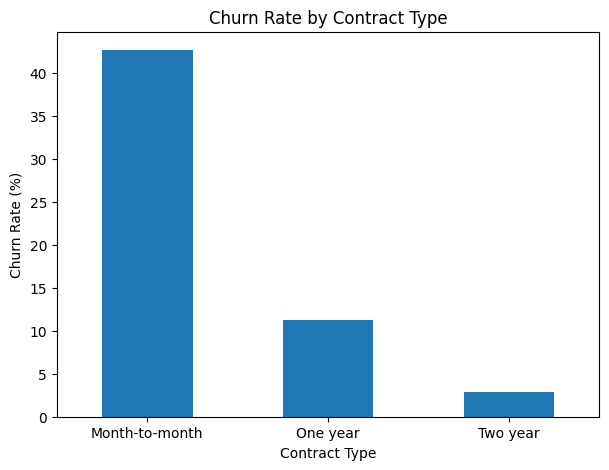

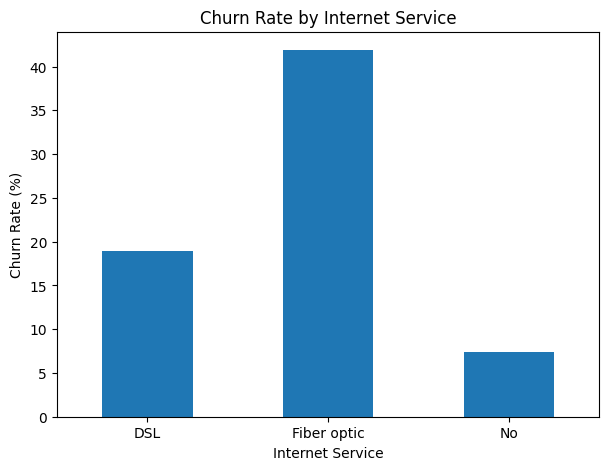

In [6]:
# Churn rate by Contract
plt.figure(figsize=(7,5))
contract_churn['Yes'].plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

# Churn rate by Internet Service
plt.figure(figsize=(7,5))
internet_churn['Yes'].plot(kind='bar')
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [8]:
# ==============================
# CHI-SQUARE TESTS
# ==============================

variables = ['InternetService', 'Contract', 'SeniorCitizen']

print("CHI-SQUARE TEST RESULTS")
print("=" * 50)

for variable in variables:
    table = pd.crosstab(df[variable], df['Churn'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"\n{variable}")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-Value: {p_value:.4e}")

    if p_value < 0.05:
        print("Result: Significant relationship with Churn")
    else:
        print("Result: No significant relationship with Churn")


# ==============================
# T-TEST: MONTHLY CHARGES
# ==============================

churned_monthly = df[df['Churn'] == 'Yes']['MonthlyCharges']
non_churned_monthly = df[df['Churn'] == 'No']['MonthlyCharges']

t_monthly, p_monthly = ttest_ind(
    churned_monthly,
    non_churned_monthly,
    equal_var=False
)

print("\n" + "=" * 50)
print("T-TEST: MONTHLY CHARGES")
print("=" * 50)

print(f"T-Statistic: {t_monthly:.4f}")
print(f"P-Value: {p_monthly:.4e}")
print(f"Churned Mean: {churned_monthly.mean():.2f}")
print(f"Non-Churned Mean: {non_churned_monthly.mean():.2f}")




CHI-SQUARE TEST RESULTS

InternetService
Chi-Square Statistic: 732.3096
P-Value: 9.5718e-160
Result: Significant relationship with Churn

Contract
Chi-Square Statistic: 1184.5966
P-Value: 5.8630e-258
Result: Significant relationship with Churn

SeniorCitizen
Chi-Square Statistic: 159.4263
P-Value: 1.5101e-36
Result: Significant relationship with Churn

T-TEST: MONTHLY CHARGES
T-Statistic: 18.4075
P-Value: 8.5924e-73
Churned Mean: 74.44
Non-Churned Mean: 61.27


In [9]:
# Convert TotalCharges from text to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Replace any missing values created during conversion
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print(df['TotalCharges'].dtype)
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

float64
Missing TotalCharges: 0


In [10]:
# ==============================
# T-TEST: TOTAL CHARGES
# ==============================

churned_total = df[df['Churn'] == 'Yes']['TotalCharges']
non_churned_total = df[df['Churn'] == 'No']['TotalCharges']

t_total, p_total = ttest_ind(
    churned_total,
    non_churned_total,
    equal_var=False
)

print("\n" + "=" * 50)
print("T-TEST: TOTAL CHARGES")
print("=" * 50)

print(f"T-Statistic: {t_total:.4f}")
print(f"P-Value: {p_total:.4e}")
print(f"Churned Mean: {churned_total.mean():.2f}")
print(f"Non-Churned Mean: {non_churned_total.mean():.2f}")


T-TEST: TOTAL CHARGES
T-Statistic: -18.7680
P-Value: 2.0591e-75
Churned Mean: 1531.80
Non-Churned Mean: 2552.88


In [11]:
# ==============================
# PREPARE DATA
# ==============================

# Convert Churn to 0 and 1
X = df.drop(columns=['Churn', 'customerID'])
y = (df['Churn'] == 'Yes').astype(int)

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])


# ==============================
# LOGISTIC REGRESSION
# ==============================

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight={0: 1, 1: 3}
    ))
])

logistic_model.fit(X_train, y_train)

log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]


# ==============================
# DECISION TREE
# ==============================

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

tree_pred = decision_tree_model.predict(X_test)
tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]


# ==============================
# MODEL EVALUATION
# ==============================

models = {
    'Logistic Regression': (log_pred, log_prob),
    'Decision Tree': (tree_pred, tree_prob)
}

results = []

for name, (pred, prob) in models.items():

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ]
)

print("MODEL PERFORMANCE")
print("=" * 70)
print(results_df.to_string(index=False))

MODEL PERFORMANCE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.728176   0.492611 0.802139  0.610376 0.841445
      Decision Tree  0.730305   0.495082 0.807487  0.613821 0.829847


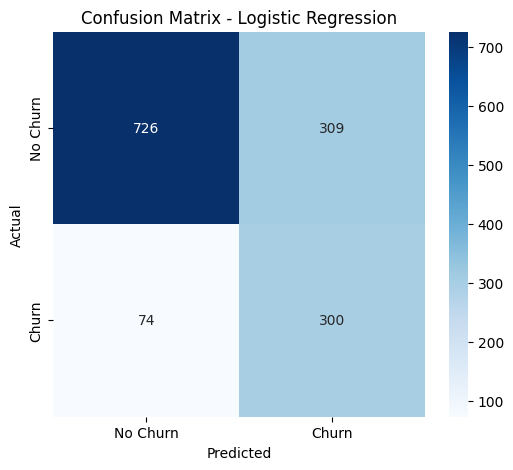

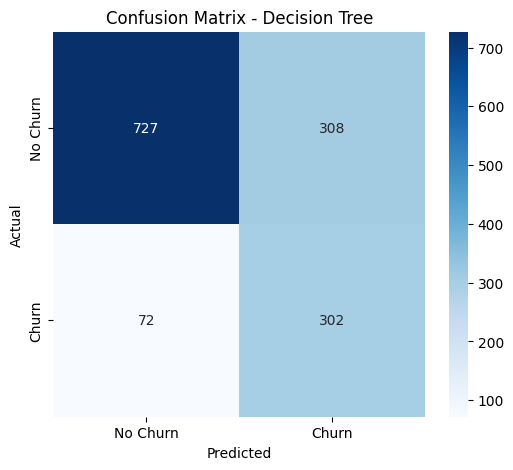

In [12]:
# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Confusion Matrix - Decision Tree
cm_tree = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

TOP 5 FEATURES CONTRIBUTING TO CHURN
        Feature  Importance
         tenure    0.154746
InternetService    0.065031
 MonthlyCharges    0.049511
       Contract    0.039689
   TotalCharges    0.011646


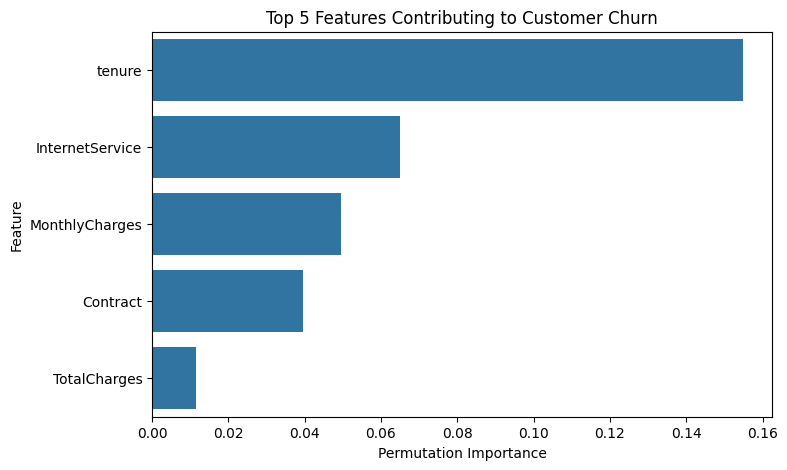

In [13]:
# ==============================
# TOP 5 FEATURE IMPORTANCE
# ==============================

importance = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importance.importances_mean
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("TOP 5 FEATURES CONTRIBUTING TO CHURN")
print("=" * 50)
print(feature_importance.head(5).to_string(index=False))

# Plot Top 5
top5 = feature_importance.head(5)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top5,
    x='Importance',
    y='Feature'
)

plt.title('Top 5 Features Contributing to Customer Churn')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.show()

CORRELATION MATRIX
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn
SeniorCitizen           1.000   0.017           0.220         0.103  0.151
tenure                  0.017   1.000           0.248         0.825 -0.352
MonthlyCharges          0.220   0.248           1.000         0.651  0.193
TotalCharges            0.103   0.825           0.651         1.000 -0.199
Churn                   0.151  -0.352           0.193        -0.199  1.000


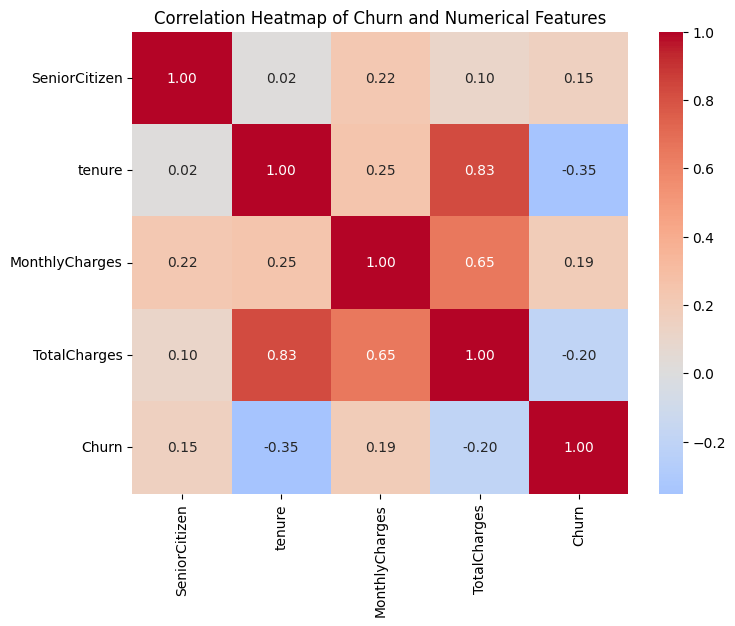

In [15]:
# ==============================
# CORRELATION ANALYSIS
# ==============================

# Convert Churn to numerical form
correlation_df = df[
    ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
].copy()

correlation_df['Churn'] = (
    df['Churn'] == 'Yes'
).astype(int)

# Correlation matrix
correlation_matrix = correlation_df.corr()

print("CORRELATION MATRIX")
print("=" * 50)
print(correlation_matrix.round(3))

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Churn and Numerical Features')
plt.show()

In [16]:
# ==============================
# FINAL FINDINGS
# ==============================

print("FINAL FINDINGS - CUSTOMER CHURN")
print("=" * 60)

print("\n1. TOP 3 STATISTICALLY SIGNIFICANT FACTORS")
print("-" * 60)

print("1. Contract Type")
print("   Month-to-month customers have the highest churn rate.")

print("\n2. Internet Service")
print("   Fiber optic customers have the highest churn rate among")
print("   the InternetService categories.")

print("\n3. Monthly Charges")
print("   Churned customers have significantly higher monthly charges")
print("   than non-churned customers.")

print("\n2. MODEL PERFORMANCE")
print("-" * 60)
print(f"Logistic Regression Recall: {results_df.loc[0, 'Recall']:.2%}")
print(f"Decision Tree Recall:       {results_df.loc[1, 'Recall']:.2%}")

print("\nBoth models achieve the required Recall >= 80%.")

print("\n3. ACTIONABLE BUSINESS INSIGHTS")
print("-" * 60)

print("Insight 1:")
print("Encourage month-to-month customers to switch to one-year")
print("or two-year contracts using discounts, loyalty benefits,")
print("or special upgrade offers.")

print("\nInsight 2:")
print("Investigate high churn among Fiber optic customers and")
print("provide targeted retention offers, service-quality support,")
print("and competitive pricing.")

print("\n4. CONCLUSION")
print("-" * 60)
print("Customer churn is strongly associated with contract type,")
print("internet service, and customer charges. The predictive")
print("models successfully achieve more than 80% recall for")
print("identifying customers likely to churn.")

FINAL FINDINGS - CUSTOMER CHURN

1. TOP 3 STATISTICALLY SIGNIFICANT FACTORS
------------------------------------------------------------
1. Contract Type
   Month-to-month customers have the highest churn rate.

2. Internet Service
   Fiber optic customers have the highest churn rate among
   the InternetService categories.

3. Monthly Charges
   Churned customers have significantly higher monthly charges
   than non-churned customers.

2. MODEL PERFORMANCE
------------------------------------------------------------
Logistic Regression Recall: 80.21%
Decision Tree Recall:       80.75%

Both models achieve the required Recall >= 80%.

3. ACTIONABLE BUSINESS INSIGHTS
------------------------------------------------------------
Insight 1:
Encourage month-to-month customers to switch to one-year
or two-year contracts using discounts, loyalty benefits,
or special upgrade offers.

Insight 2:
Investigate high churn among Fiber optic customers and
provide targeted retention offers, service-qu